📥 Chargement des données...
🎯 Séparation X / y...
✂️ Train/Test split...
🔢 Encoding...
✅ Colonnes de fuite supprimées et encodage terminé !
Colonnes fortement corrélées avec Churn :
 Churn    1.0
Name: Churn, dtype: float64
🧹 Nettoyage...
📏 Scaling...
⚖️ SMOTE...
✅ Preprocessing terminé !
✅ pas de fuite détectée !
Train distribution:
Churn
0    2334
1    1163
Name: count, dtype: int64

Test distribution:
Churn
0    584
1    291
Name: count, dtype: int64


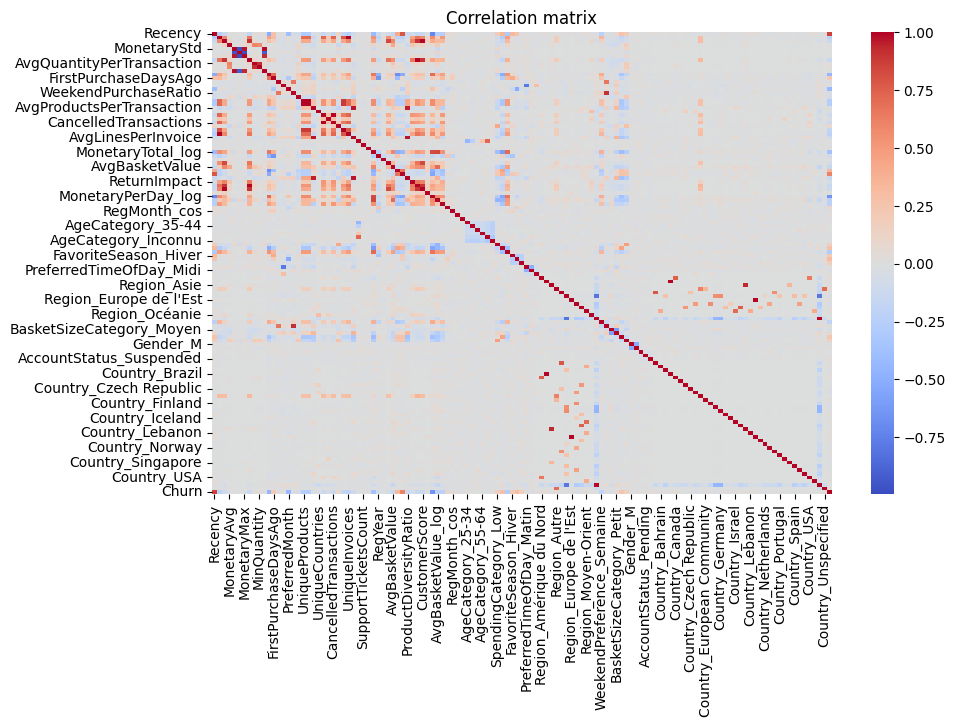

Accuracy random test: 0.5382857142857143
            Recency     Frequency  MonetaryTotal   MonetaryAvg   MonetaryStd  \
count  3.497000e+03  3.497000e+03   3.497000e+03  3.497000e+03  3.497000e+03   
mean   4.876473e-17  2.031864e-18  -1.523898e-17 -3.047796e-18 -7.111523e-18   
std    1.000143e+00  1.000143e+00   1.000143e+00  1.000143e+00  1.000143e+00   
min   -9.066634e-01 -4.219429e-01  -8.137327e-01 -3.146131e+01 -3.506133e-02   
25%   -7.474227e-01 -4.219429e-01  -2.114755e-01 -1.368399e-01 -3.296706e-02   
50%   -4.189887e-01 -2.179990e-01  -1.648750e-01 -9.455335e-02 -3.156892e-02   
75%    5.065979e-01  8.791692e-02  -3.594135e-02 -4.510005e-02 -2.809448e-02   
max    2.805636e+00  2.476513e+01   3.342893e+01  2.791553e+01  4.572501e+01   

        MonetaryMin   MonetaryMax  TotalQuantity  AvgQuantityPerTransaction  \
count  3.497000e+03  3.497000e+03    3497.000000               3.497000e+03   
mean   7.619489e-18  1.523898e-18       0.000000              -2.768414e-17   
s

In [6]:

import sys
sys.path.append('../src')
from preprocessing import preprocess_pipeline

X_train, X_test, y_train, y_test, X_train_smote, y_train_smote, scaler = preprocess_pipeline(
    '../data/processed/step3_feature_engineering.csv'
)

# ✔ Vérification distribution
print("Train distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

# ✔ Correlation
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_check = pd.concat([X_train, y_train], axis=1)

plt.figure(figsize=(10,6))
sns.heatmap(df_check.corr(), cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

# ✔ Colonnes suspectes
for col in X_train.columns:
    if "churn" in col.lower():
        print("⚠️ colonne suspecte :", col)

# ✔ Test random
from sklearn.metrics import accuracy_score
import numpy as np

y_random = np.random.permutation(y_test)

print("Accuracy random test:",
      accuracy_score(y_random, y_test))

# ✔ Statistiques
print(X_train.describe())


⚠ Colonnes fortement corrélées avec Churn (>0.9) :
Churn    1.0
Name: Churn, dtype: float64
Colonnes catégorielles : Index(['RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType',
       'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel',
       'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory',
       'ProductDiversity', 'Gender', 'AccountStatus', 'Country'],
      dtype='str')

--- RFMSegment ---
Churn          0    1
RFMSegment           
Champions    979    0
Dormants       0  627
Fidèles     1067  110
Potentiels   872  717

--- AgeCategory ---
Churn          0    1
AgeCategory          
18-24        233  104
25-34        292  182
35-44        330  165
45-54        342  173
55-64        305  144
65+          536  255
Inconnu      880  431

--- SpendingCategory ---
Churn                0    1
SpendingCategory           
High              1243  421
Low                 73  142
Medium             790  827
VIP                812   64

--- CustomerType

C:\Users\chaie\AppData\Local\Temp\ipykernel_5168\917966361.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


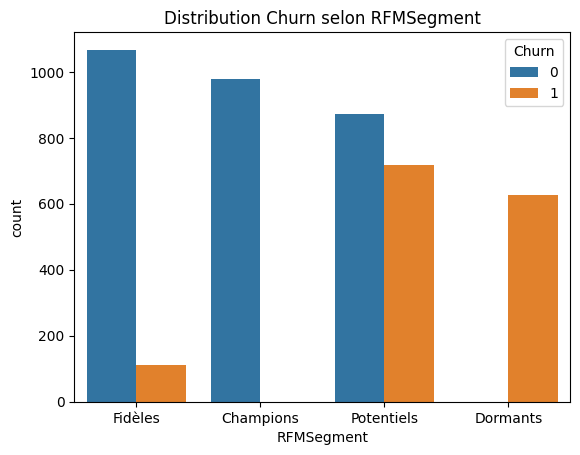

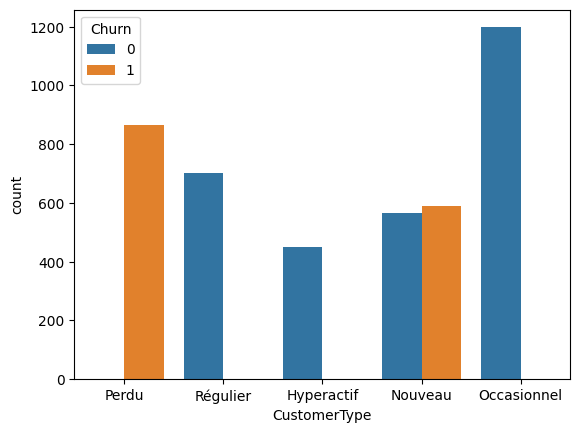

In [7]:
import pandas as pd

# Charger les données (raw ou après encoding mais avant SMOTE)
df = pd.read_csv('../data/processed/step3_feature_engineering.csv')

# Séparer X / y
X = df.drop(columns=['Churn'])
y = df['Churn']

# Pour vérifier la corrélation uniquement sur les colonnes numériques
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
corr_matrix = pd.concat([X[numeric_cols], y], axis=1).corr()['Churn'].sort_values(ascending=False)

# Afficher les colonnes très corrélées
print("⚠ Colonnes fortement corrélées avec Churn (>0.9) :")
print(corr_matrix[corr_matrix > 0.9])


# Colonnes object avant encoding
cat_cols = df.select_dtypes(include=['object']).columns
print("Colonnes catégorielles :", cat_cols)

# Vérifier leur relation avec Churn
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(pd.crosstab(df[col], y))

from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()
    x = le.fit_transform(df[col])
    chi, p = chi2(x.reshape(-1,1), df['Churn'])
    print(f"{col}: chi2={chi[0]:.2f}, p-value={p[0]:.5f}")

import seaborn as sns
import matplotlib.pyplot as plt

# Exemple pour RFMSegment
sns.countplot(x='RFMSegment', hue='Churn', data=df)
plt.title("Distribution Churn selon RFMSegment")
plt.show()

# Même pour CustomerType ou LoyaltyLevel
sns.countplot(x='CustomerType', hue='Churn', data=df)
plt.show()



In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

model = RandomForestClassifier(random_state=42)

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')

print("F1 scores:", scores)
print("Mean F1:", np.mean(scores))


F1 scores: [1.         1.         0.995671   0.99784017 1.        ]
Mean F1: 0.9987022336914346
